In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tkinter as tk
from tkinter import filedialog
import mne
import pickle
import yaml
import time

from mne.decoding import CSP

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import confusion_matrix, balanced_accuracy_score
from sklearn.model_selection import GroupKFold, GroupShuffleSplit
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import balanced_accuracy_score, confusion_matrix

mne.set_log_level('WARNING')

from scipy.signal import butter, sosfilt, sosfilt_zi


In [2]:
def print_cm(cm, title, tick_labels):
    plt.figure(figsize=(4, 3))
    ax = sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    ax.set_xticklabels(tick_labels)
    ax.set_yticklabels(tick_labels)
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.title(title)
    plt.show()

def get_fisher_score(X, y, classes):
    mu1 = np.mean(X[y == classes[0]], axis=0)
    sigma1 = np.std(X[y == classes[0]], axis=0)
    mu2 = np.mean(X[y == classes[1]], axis=0)
    sigma2 = np.std(X[y == classes[1]], axis=0)
    fisher = np.abs(mu1 - mu2)**2 / (sigma1**2 + sigma2**2 + 1e-10)
    return fisher


In [11]:
root = tk.Tk()
root.withdraw() 

current_dir = os.getcwd()
current_dir = os.path.dirname(current_dir)
current_dir = os.path.dirname(current_dir)
current_dir = os.path.dirname(current_dir)

filenames = filedialog.askopenfilenames(
    title="Seleziona i file GDF", 
    filetypes=[("GDF Files", "*.gdf")],
    initialdir=current_dir
)

if not filenames:
    print("Nessun file selezionato!")
else:
    print(f"Selezionati {len(filenames)} file:")
    for f in filenames:
        print(f" - {f}")

    paradigm = os.path.splitext(os.path.basename(filenames[0]))[0].split('.')[-1]
    subject = os.path.splitext(os.path.basename(filenames[0]))[0].split('.')[0]
    
    # Determina le classi in base al nome del file
    if 'cvsa' in paradigm.lower():
        paradigm_to_save = 'cvsa'
        classes = ['730', '731']
    elif 'mi' in paradigm.lower():
        classes = ['769', '770']
        paradigm_to_save = 'mi'
    else:
        classes = ['771', '773']
        
    print(f"Paradigma: {paradigm}")
    print(f"Soggetto: {subject}")
    print(f"Classi: {classes}")

Selezionati 2 file:
 - /home/paolo/bci_vr_ws/recordings/c7/20260428/calibration/gdf/c7.20260428.124418.calibration.cvsa_blbr.gdf
 - /home/paolo/bci_vr_ws/recordings/c7/20260428/calibration/gdf/c7.20260428.124824.calibration.cvsa_blbr.gdf
Paradigma: cvsa_blbr
Soggetto: c7
Classi: ['730', '731']


In [20]:
# Preprocessing and Epoching Parameters
FREQ = 500
CHUNK_SIZE = 25 # ~62.5 ms at 128Hz
WINDOW_SIZE = FREQ * 1 # 1 second window

BANDS = [[8, 10], [10, 12], [12, 14], [8, 14], [14, 20]]
BANDS_STR = [f"{b[0]}-{b[1]}Hz" for b in BANDS]

N_CHANNELS = 32
N_CSP_COMPONENTS = 4  # top 2 + bottom 2 for band
EXCLUDE_CHANNELS = ['Fp1', 'Fp2'] # Optionally exclude channels

CVSA_INFLUENCE = 3.5 # None if all the cf, otherwise you can choose

if 'mi' in paradigm.lower():
    SELECTED_CHANNELS = ['FC5', 'FC1', 'C3', 'CP5', 'CP1', 'CP6', 'CP2', 'Cz', 'C4', 'FC6', 'FC2']
elif 'cvsa' in paradigm.lower():
    SELECTED_CHANNELS = ['P7', 'P3', 'Pz', 'P4', 'P8', 'O1', 'Oz', 'O2']


In [21]:
raw_list = []
for f in filenames:
    with mne.utils.use_log_level('ERROR'):
        raw = mne.io.read_raw_gdf(f, preload=True)
        raw = raw.pick(list(range(N_CHANNELS)))
    
        # my car excluding fp1 and fp2
        data = raw.get_data() 
        excl_idx = [raw.ch_names.index(ch) for ch in EXCLUDE_CHANNELS if ch in raw.ch_names]
        include_mask = np.ones(N_CHANNELS, dtype=bool)
        include_mask[excl_idx] = False
        common_avg = data[include_mask, :].mean(axis=0)  
        data -= common_avg[np.newaxis, :] 
        raw._data = data
    
    raw_list.append(raw)


SELECTED_INDEX_CH = [raw.ch_names.index(ch) for ch in SELECTED_CHANNELS if ch in raw.ch_names]

# Extract 1-second sliding windows during continuous feedback (event 781)
X_epochs = []
y_epochs = []
trials = []
trial_idx = 0

all_X_band = [] # Will store band-filtered windows

for raw in raw_list:
    # Get annotations
    cf_segments = []
    current_class = None
    onset_sample = None # Variabile per salvare l'inizio del feedback
    
    for annot in raw.annotations:
        desc = annot['description']
        
        if desc in classes:
            current_class = desc
            
        elif desc == '781':
            onset_sample = int(annot['onset'] * FREQ)
            
        elif desc == '33549':
            if current_class is not None and onset_sample is not None:
                end_sample = int(annot['onset'] * FREQ)
                duration_samples = end_sample - onset_sample
                
                # Salviamo onset, duration calcolata e classe
                cf_segments.append((onset_sample, duration_samples, current_class))
                
                # Reset delle variabili per il trial successivo
                current_class = None
                onset_sample = None
                
    # Causal bandpass: LP then HP, matching ROS Fbcsp.cpp (filters_low_[i] → filters_high_[i])
    raw_bands = []
    data_car = raw.get_data()  # CAR already applied above
    for l_freq, h_freq in BANDS:
        sos_lp = butter(4, h_freq, btype='lowpass',  fs=FREQ, output='sos')
        sos_hp = butter(4, l_freq, btype='highpass', fs=FREQ, output='sos')

        zi_lp = sosfilt_zi(sos_lp)
        zi_lp = np.broadcast_to(zi_lp[:, np.newaxis, :], (zi_lp.shape[0], data_car.shape[0], 2)).copy()
        data_lp, _ = sosfilt(sos_lp, data_car, zi=zi_lp)

        zi_hp = sosfilt_zi(sos_hp)
        zi_hp = np.broadcast_to(zi_hp[:, np.newaxis, :], (zi_hp.shape[0], data_lp.shape[0], 2)).copy()
        filtered, _ = sosfilt(sos_hp, data_lp, zi=zi_hp)

        raw_bands.append(filtered)
        
    for onset, duration, cls in cf_segments:
        end = onset + duration
        # For CVSA, optionally limit windows to the first CVSA_INFLUENCE seconds of each trial
        if paradigm_to_save == 'cvsa' and CVSA_INFLUENCE is not None:
            end = min(end, onset + int(CVSA_INFLUENCE * FREQ))
        
        # Sliding window from onset to end - window_size, step by chunk_size
        for s in range(onset, end - WINDOW_SIZE + 1, CHUNK_SIZE):
            window_bands = []
            for b in range(len(BANDS)):
                window_bands.append(raw_bands[b][:, s : s + WINDOW_SIZE])
            X_epochs.append(np.array(window_bands))
            y_epochs.append(cls)
            trials.append(trial_idx)
        trial_idx += 1

X_epochs = np.array(X_epochs) # Shape: (n_epochs, n_bands, n_channels, n_samples)
y_epochs = np.array(y_epochs)
trials = np.array(trials)

print(f"Extracted {len(X_epochs)} windows across {len(np.unique(trials))} trials.")
print(f"X_epoch shape: {X_epochs.shape} (n_epochs, n_bands, n_channels, n_samples)")

Extracted 2040 windows across 40 trials.
X_epoch shape: (2040, 5, 32, 500) (n_epochs, n_bands, n_channels, n_samples)


CSP for band [8, 10]
CSP for band [10, 12]
CSP for band [12, 14]
CSP for band [8, 14]
CSP for band [14, 20]


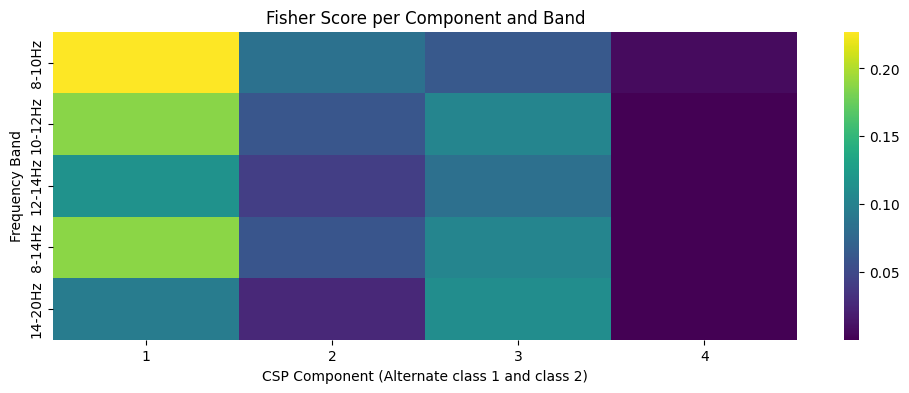

In [22]:
# Fit CSP per band to compute Fisher Scores
csp_list = [CSP(n_components=N_CSP_COMPONENTS, reg='ledoit_wolf', log=True, norm_trace=False, component_order='alternate') for _ in range(len(BANDS))]

fisher_scores = np.zeros((len(BANDS), N_CSP_COMPONENTS))
X_csp_all = np.zeros((len(X_epochs), len(BANDS), N_CSP_COMPONENTS))

for b in range(len(BANDS)):
    print(f"CSP for band {BANDS[b]}")
    X_b = X_epochs[:, b, SELECTED_INDEX_CH, :]
    csp_list[b].fit(X_b, y_epochs)
    X_csp_all[:, b, :] = csp_list[b].transform(X_b)
    
    # Compute Fisher score
    fisher_scores[b, :] = get_fisher_score(X_csp_all[:, b, :], y_epochs, classes)

# Plot Fisher Scores
plt.figure(figsize=(12, 4))
sns.heatmap(fisher_scores, annot=False, cmap='viridis', xticklabels=np.arange(1, N_CSP_COMPONENTS+1), yticklabels=BANDS_STR)
plt.title('Fisher Score per Component and Band')
plt.xlabel('CSP Component (Alternate class 1 and class 2)')
plt.ylabel('Frequency Band')
plt.show()

Feature matrix shape: (2040, 20)
--- FASE 1: Valutazione con 5-Fold CV ---
Fold 1 - Train Balanced Accuracy: 0.7653, Test Balanced Accuracy: 0.6324
Fold 2 - Train Balanced Accuracy: 0.8033, Test Balanced Accuracy: 0.5245
Fold 3 - Train Balanced Accuracy: 0.7953, Test Balanced Accuracy: 0.5245
Fold 4 - Train Balanced Accuracy: 0.7279, Test Balanced Accuracy: 0.7623
Fold 5 - Train Balanced Accuracy: 0.7347, Test Balanced Accuracy: 0.6201

RISULTATO VALUTAZIONE: Test average Balanced Accuracy: 0.6127 ± 0.0876


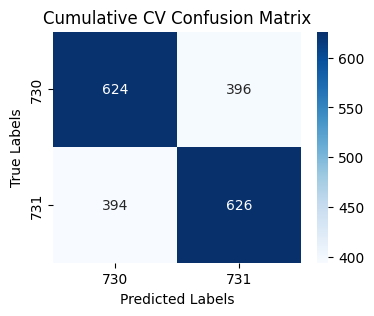


--- FASE 2: Addestramento Modello Finale per Produzione ---
Modello Finale addestrato su 2040 epoche totali.
Training Accuracy Globale: 0.7446


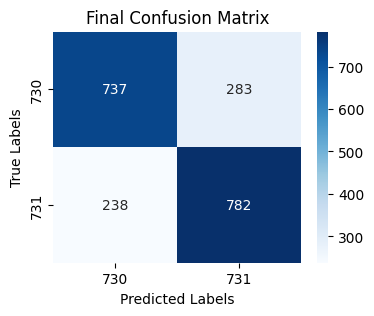

In [23]:
selected_indices = list(range(N_CSP_COMPONENTS))

X_features = np.zeros((len(X_epochs), len(BANDS) * N_CSP_COMPONENTS))

for b in range(len(BANDS)):
    X_features[:, b * N_CSP_COMPONENTS : (b+1) * N_CSP_COMPONENTS] = X_csp_all[:, b, selected_indices]
    
print(f"Feature matrix shape: {X_features.shape}")

# ==========================================================
K_FOLDS = 5
sgkf = StratifiedGroupKFold(n_splits=K_FOLDS)

fold_accuracies = []
cms = []

print(f"--- FASE 1: Valutazione con {K_FOLDS}-Fold CV ---")
for fold_idx, (train_idx, test_idx) in enumerate(sgkf.split(X_features, y_epochs, groups=trials), 1):
    
    X_train, y_train = X_features[train_idx], y_epochs[train_idx]
    X_test, y_test = X_features[test_idx], y_epochs[test_idx]
    
    clf_cv = LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto', priors=[0.5, 0.5])
    clf_cv.fit(X_train, y_train)
    
    y_pred = clf_cv.predict(X_test)
    acc = balanced_accuracy_score(y_test, y_pred)

    y_pred_train = clf_cv.predict(X_train)
    acc_train = balanced_accuracy_score(y_train, y_pred_train)
    
    fold_accuracies.append(acc)
    cms.append(confusion_matrix(y_test, y_pred, labels=classes))
    
    print(f"Fold {fold_idx} - Train Balanced Accuracy: {acc_train:.4f}, Test Balanced Accuracy: {acc:.4f}")

mean_acc = np.mean(fold_accuracies)
std_acc = np.std(fold_accuracies)
mean_cm = np.sum(cms, axis=0)

print(f"\nRISULTATO VALUTAZIONE: Test average Balanced Accuracy: {mean_acc:.4f} ± {std_acc:.4f}")
print_cm(mean_cm, "Cumulative CV Confusion Matrix", classes)


# ==========================================================
print("\n--- FASE 2: Addestramento Modello Finale per Produzione ---")

clf_final = LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto', priors=[0.5, 0.5])
clf_final.fit(X_features, y_epochs)

y_pred_final = clf_final.predict(X_features)
final_train_acc = balanced_accuracy_score(y_epochs, y_pred_final)
cms_final = confusion_matrix(y_epochs, y_pred_final, labels=classes)
print(f"Modello Finale addestrato su {len(X_features)} epoche totali.")
print(f"Training Accuracy Globale: {final_train_acc:.4f}")
print_cm(cms_final, "Final Confusion Matrix", classes)

In [24]:
time_str = time.strftime('%d%m%Y_%H%M%S')

csp_matrices = []
for b in range(len(BANDS)):
    csp = csp_list[b]
    filters = csp.filters_
    sel_filters = filters[selected_indices, :]
    csp_matrices.append(sel_filters.tolist())

csp_dict = {
    'CspCfg': {
        'params':{
            'filenames': list(filenames), 
            'subject': subject,
            'name': 'csp',
            'classes': [str(c) for c in classes],
            'bands': BANDS,
            'selected_components_indices': selected_indices,
            'selected_channels': SELECTED_CHANNELS,   # channel names used – loaded by Fbcsp.cpp
            'csp_matrices': csp_matrices
        }
    }
}

yaml_csp_filename = current_dir + f'/src/processing_bci/cfg/csp/{paradigm_to_save}/csp_{subject}_{time_str}.yaml'
with open(yaml_csp_filename, 'w') as f:
    yaml.dump(csp_dict, f, default_flow_style=False, sort_keys=False)
print(f"[OK] CSP matrices saved in {yaml_csp_filename}")
#print(f"     Channels ({len(SELECTED_CHANNELS)}): {SELECTED_CHANNELS}")


slda_weights = clf_final.coef_.tolist()
slda_intercept = clf_final.intercept_.tolist()

slda_dict = {
    'sLDACfg':{
        'params':{
            'filenames': list(filenames), 
            'subject': subject,
            'name': 'slda',
            'classes': [str(c) for c in classes],
            'bands': BANDS,
            'selected_components_indices': selected_indices,
            'selected_channels': SELECTED_CHANNELS,   # channel names used for CSP
            'cv_mean_acc': float(mean_acc),
            'cv_std_acc': float(std_acc),
            'confusion_matrix': mean_cm.tolist(),
            'csp': yaml_csp_filename,
            'slda_weights': slda_weights,
            'slda_intercept': slda_intercept
        }
    }
}

yaml_metadata_filename = current_dir + f'/src/slda_bci/models/{paradigm_to_save}/slda_{subject}_{time_str}.yaml'
with open(yaml_metadata_filename, 'w') as f:
    yaml.dump(slda_dict, f, default_flow_style=False, sort_keys=False)
print(f"[OK] sLDA model saved in {yaml_metadata_filename}")


[OK] CSP matrices saved in /home/paolo/bci_vr_ws/src/processing_bci/cfg/csp/cvsa/csp_c7_14052026_154218.yaml
[OK] sLDA model saved in /home/paolo/bci_vr_ws/src/slda_bci/models/cvsa/slda_c7_14052026_154218.yaml



Spatial pattern band: 8-10Hz:
[OK] Topoplot saved in: /home/paolo/bci_vr_ws/images/c7/csp/topoplot_c7_8_10Hz_mi_lhrh.png

Spatial pattern band: 10-12Hz:
[OK] Topoplot saved in: /home/paolo/bci_vr_ws/images/c7/csp/topoplot_c7_10_12Hz_mi_lhrh.png

Spatial pattern band: 12-14Hz:
[OK] Topoplot saved in: /home/paolo/bci_vr_ws/images/c7/csp/topoplot_c7_12_14Hz_mi_lhrh.png

Spatial pattern band: 8-14Hz:
[OK] Topoplot saved in: /home/paolo/bci_vr_ws/images/c7/csp/topoplot_c7_8_14Hz_mi_lhrh.png

Spatial pattern band: 14-20Hz:
[OK] Topoplot saved in: /home/paolo/bci_vr_ws/images/c7/csp/topoplot_c7_14_20Hz_mi_lhrh.png


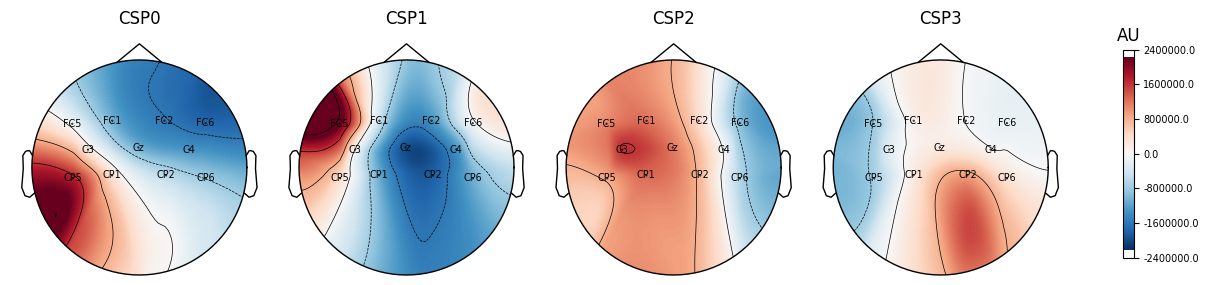

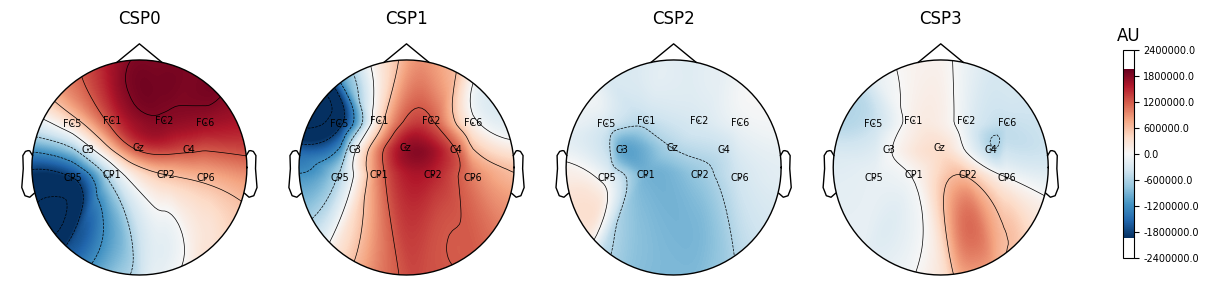

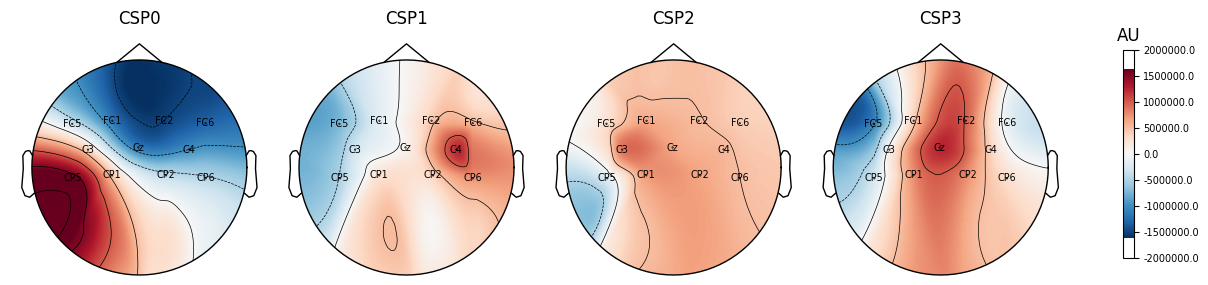

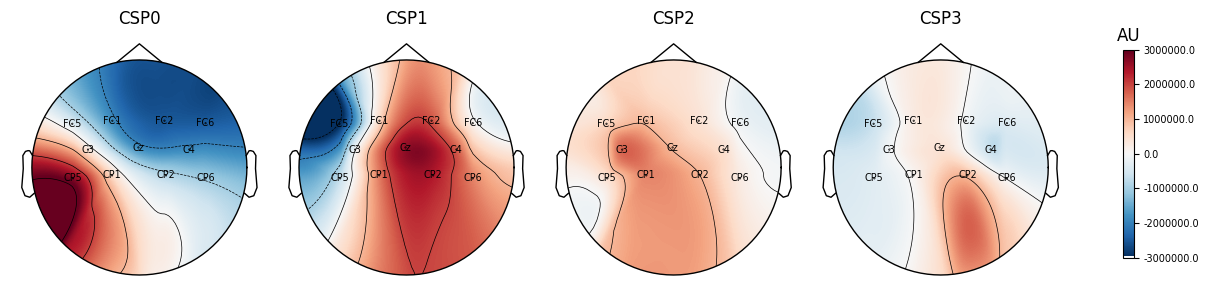

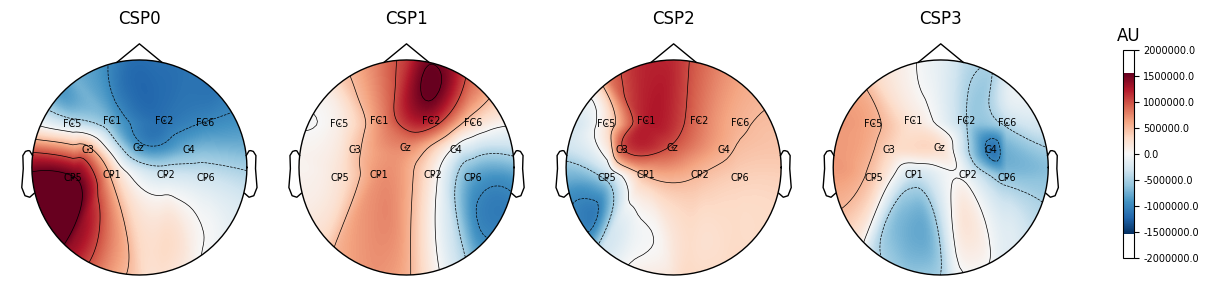

In [10]:
plot_dir = os.path.join(current_dir, f"images/{subject}/csp")
os.makedirs(plot_dir, exist_ok=True)

info_full = raw_list[0].info
montage = mne.channels.make_standard_montage('standard_1020')
info_full.set_montage(montage, on_missing='ignore')
info_limited = mne.pick_info(info_full, sel=SELECTED_INDEX_CH)

for b in range(len(BANDS)):
    print(f"\nSpatial pattern band: {BANDS_STR[b]}:")
    
    fig = csp_list[b].plot_patterns(info_limited, 
                                    components=selected_indices, 
                                    size=2.0, 
                                    show_names=True,
                                    show=False) 
    
    clean_band_name = BANDS_STR[b].replace("-", "_").replace(" ", "")
    
    plot_filename = os.path.join(plot_dir, f"topoplot_{subject}_{clean_band_name}_{paradigm}.png")
    
    fig.savefig(plot_filename, dpi=300, bbox_inches='tight', transparent=False)
    
    print(f"[OK] Topoplot saved in: {plot_filename}")